In [2]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn


In [4]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

In [6]:
try:
    from google.colab import files
    raw_upload = files.upload()
    file_key = list(raw_upload.keys())[0]
    df = pd.read_csv(io.BytesIO(raw_upload[file_key]))
except ModuleNotFoundError:
    # running locally, just read the csv from the same folder
    df = pd.read_csv('Country-data.csv')

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [8]:
print('Dataset dimensions:', df.shape)
print('---')
display(df.head(10))
print('---')
display(df.info())
print('---')
display(df.describe(include='all').T)

Dataset dimensions: (167, 10)
---


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


In [10]:
print('Columns found in dataset:', df.columns.tolist())

Columns found in dataset: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [11]:
df = df.copy()

# stripping spaces and lowercasing column names
df.columns = [col.strip().lower() for col in df.columns]

initial_row_count = len(df)
df = df.drop_duplicates()
print(f'Dropped {initial_row_count - len(df)} duplicate rows')

# coerce forces bad entries to NaN instead of crashing
for column in df.columns:
    if column != 'country':
        df[column] = pd.to_numeric(df[column], errors='coerce')

# using median to fill NaN since mean gets thrown off by outliers
numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

print('\nNull counts after cleaning:')
print(df.isna().sum())

Dropped 0 duplicate rows

Null counts after cleaning:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


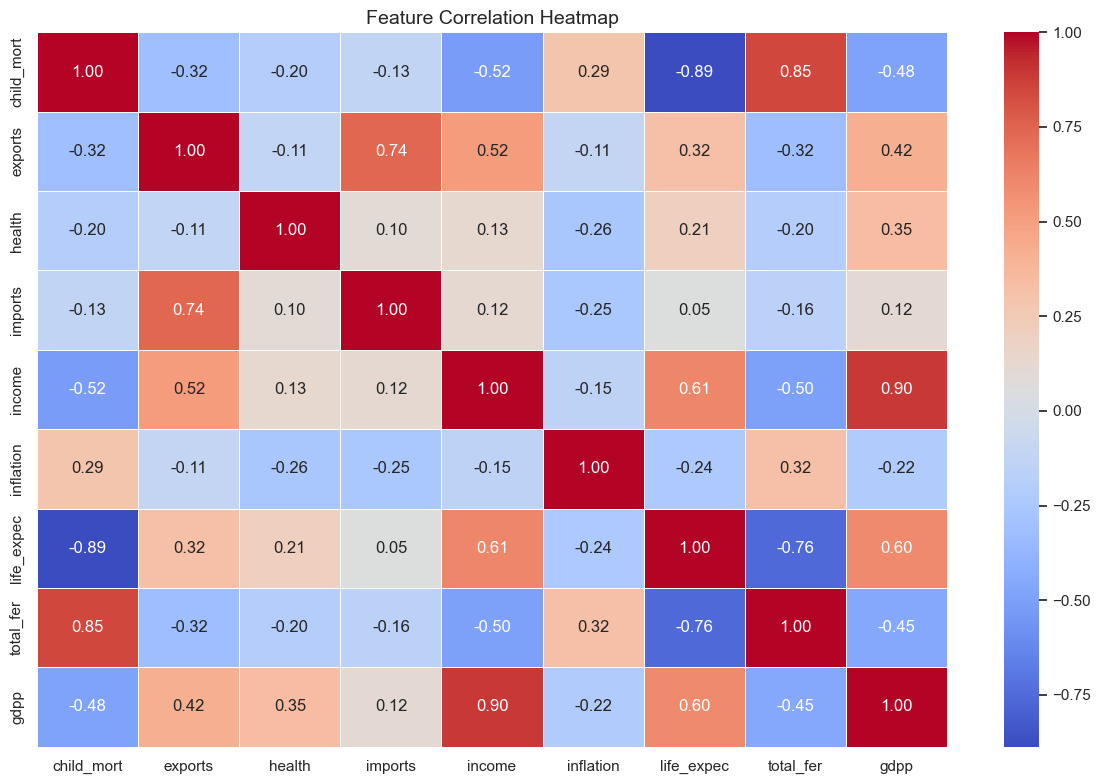

In [13]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

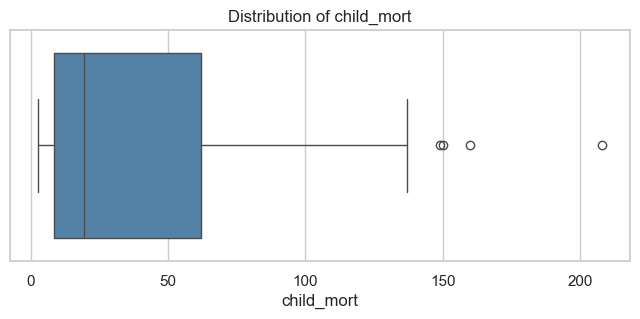

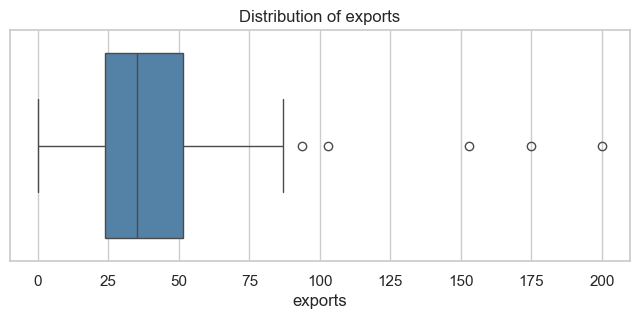

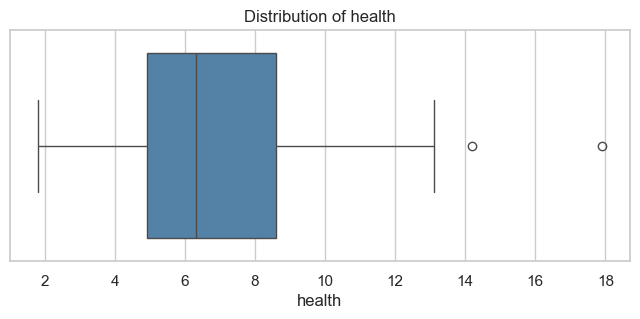

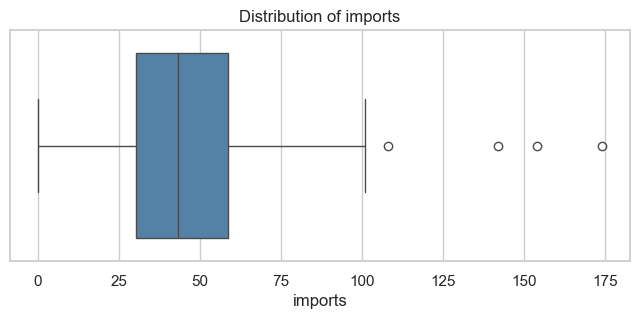

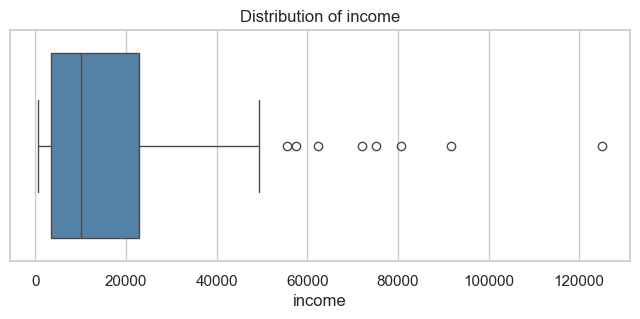

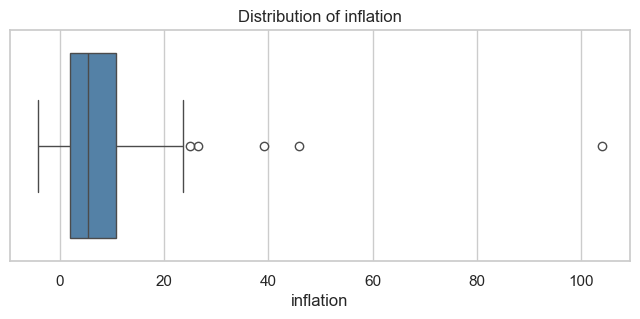

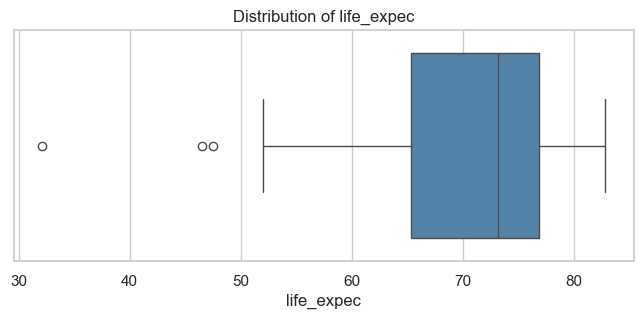

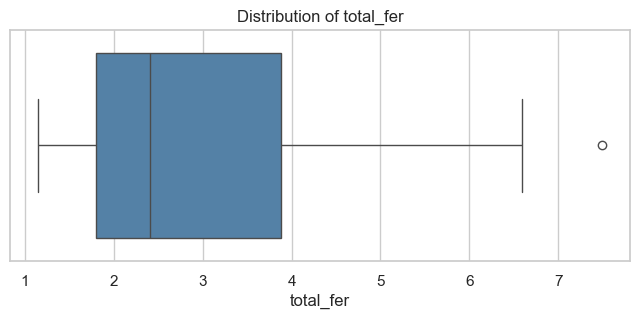

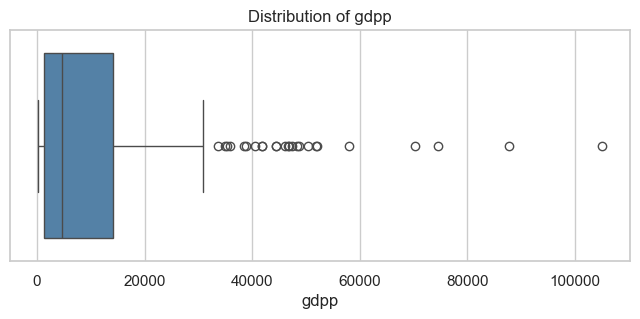

In [15]:
for column in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[column], color='steelblue')
    plt.title(f'Distribution of {column}')
    plt.show()

In [16]:
# dropping country name — only numeric cols go into the scaler
numeric_df = df.drop(columns=['country'], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

print('Scaled matrix shape:', X_scaled.shape)
print(f'Mean after scaling: {X_scaled[:, 0].mean():.6f}')  # should be ~0
print(f'Std after scaling: {X_scaled[:, 0].std():.4f}')    # should be ~1

Scaled matrix shape: (167, 9)
Mean after scaling: -0.000000
Std after scaling: 1.0000
